# AskMyBookmark — LangGraph Orchestrator Diagram

This notebook compiles the LangGraph orchestrator graph using minimal stub data (no GitHub API call, no embedding) and renders the graph diagram.

Run all cells top-to-bottom. The final cell displays the compiled graph.

## 1. Setup

In [1]:
import sys
import os

# Add the repo root to sys.path so `app.orchestrator` is importable
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Load OPENAI_API_KEY (needed for ChatOpenAI object initialisation)
from dotenv import load_dotenv
load_dotenv(".env")

True

## 2. Build minimal stub data

The orchestrator graph requires a `search_df` (with `SearchArray`-indexed BM25 columns) and a
`vector_store`. We create one-row stub versions so the graph compiles without making any API
calls or loading real data.

In [2]:
import pandas as pd
from typing import List
from langchain_core.documents import Document
from langchain_core.retrievers import BaseRetriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from searcharray import SearchArray
from app.orchestrator import _preprocess_text

# ── Minimal single-row DataFrame ──────────────────────────────────────────
stub_df = pd.DataFrame([{
    "id":                "stub-id",
    "repo":              "stub/repo",
    "description":       "stub description",
    "topics":            "stub",
    "topics_list":       ["stub"],
    "language":          "Python",
    "stars":             0,
    "url":               "https://github.com/stub/repo",
    "content":           "stub content",
    "curated_list_bm25": 0.0,
}])

# SearchArray BM25 columns required by MultiMatchBM25Retriever
stub_df["repo_idx"]        = SearchArray.index(stub_df["repo"],        tokenizer=_preprocess_text)
stub_df["description_idx"] = SearchArray.index(stub_df["description"], tokenizer=_preprocess_text)
stub_df["topics_idx"]      = SearchArray.index(stub_df["topics"],      tokenizer=_preprocess_text)
stub_df["content_idx"]     = SearchArray.index(stub_df["content"],     tokenizer=_preprocess_text)

# ── Stub vector store ──────────────────────────────────────────────────────
# EnsembleRetriever validates that its retrievers are real Runnable instances,
# so we need a proper BaseRetriever subclass rather than a MagicMock.
class _StubRetriever(BaseRetriever):
    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        return []

class _StubVectorStore:
    def as_retriever(self, **kwargs) -> _StubRetriever:
        return _StubRetriever()

stub_vector_store = _StubVectorStore()

print("Stub data ready.")
print(f"stub_df columns: {list(stub_df.columns)}")

2026-03-18 20:16:27,087 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-18 20:16:27,087 - searcharray.indexing - INFO - 0 Batch Start tokenization
2026-03-18 20:16:27,088 - searcharray.indexing - INFO - Tokenizing 1 documents
2026-03-18 20:16:28,297 - searcharray.indexing - INFO - Tokenization -- vstacking
2026-03-18 20:16:28,297 - searcharray.indexing - INFO - Tokenization -- DONE
2026-03-18 20:16:28,298 - searcharray.indexing - INFO - Inverting docs->terms
2026-03-18 20:16:28,299 - searcharray.indexing - INFO - Encoding positions to bit array
2026-03-18 20:16:28,300 - searcharray.indexing - INFO - Batch tokenization complete
2026-03-18 20:16:28,300 - searcharray.indexing - INFO - (main thread) Processing 1 batch results
2026-03-18 20:16:28,301 - searcharray.indexing - INFO - Indexing from tokenization complete
2026-03-18 20:16:28,302 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-18 20:16:28,302 - searcharray.indexing - INFO - 0 Batch Start 

## 3. Compile the orchestrator graph

In [3]:
from app.orchestrator import build_orchestrator_graph

orchestrator = build_orchestrator_graph(
    search_df=stub_df,
    vector_store=stub_vector_store,
    # No checkpointer or query_cache_dir needed for diagram rendering
)

print("Graph compiled successfully.")

Graph compiled successfully.


## 4. Display the graph

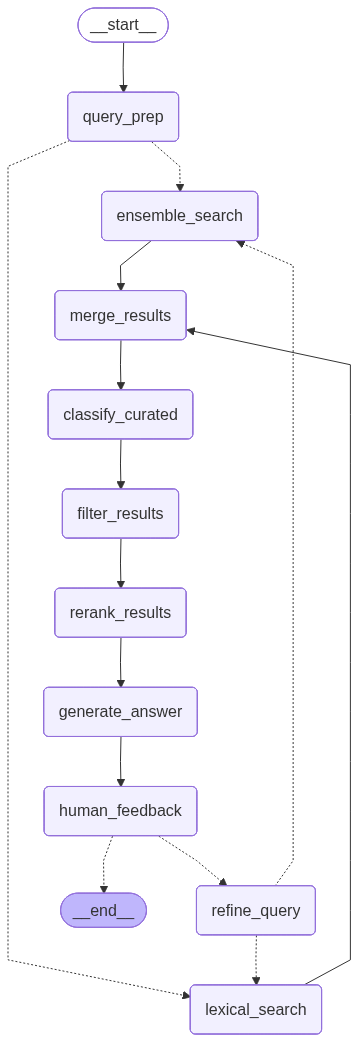

In [4]:
from IPython.display import Image, display

display(Image(orchestrator.get_graph().draw_mermaid_png()))